In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score, classification_report

df = pd.read_csv(r"C:\Users\bhaga\python\PSCompPars_2026.08.08_04.23.14.csv", comment='#')

threshold = len(df) * 0.5
df_clean = df.dropna(thresh=threshold, axis=1)

key_cols = ['pl_orbper','pl_rade','pl_bmasse','st_teff','st_rad','st_mass']
key_cols = [c for c in key_cols if c in df_clean.columns]
for col in key_cols:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

df_clean = df_clean.dropna(subset=['pl_name', 'disc_year'])
df_clean['disc_year'] = df_clean['disc_year'].astype(int)

print("Ready:", df_clean.shape)

Ready: (6336, 75)


In [2]:
df_clean['is_small_planet']=(df_clean['pl_rade']<4).astype(int)
features=['pl_orbner','pl_bmasse','st_teff','st_mass']
features=[f for f in features if f in df_clean.columns]

X = df_clean[features]
y = df_clean['is_small_planet']
print(X.shape,y.value_counts())

(6336, 3) is_small_planet
1    3903
0    2433
Name: count, dtype: int64


In [3]:
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [4]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled,y_train)
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:,1]

In [5]:
print(X_train.dtypes)
print(X_train.isna().sum())
print(y_train.isna().sum())
print(X_train.shape, y_train.shape)

pl_bmasse    float64
st_teff      float64
st_mass      float64
dtype: object
pl_bmasse    0
st_teff      0
st_mass      0
dtype: int64
0
(5068, 3) (5068,)


Accuracy: 0.8280757097791798

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.57      0.72       487
           1       0.79      0.99      0.88       781

    accuracy                           0.83      1268
   macro avg       0.88      0.78      0.80      1268
weighted avg       0.86      0.83      0.82      1268



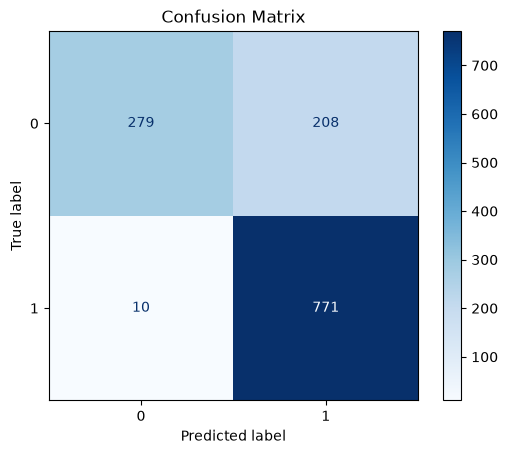

In [6]:
acc = accuracy_score(y_test, y_pred)
print('Accuracy:', acc)
print('\nClassification Report:\n', classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

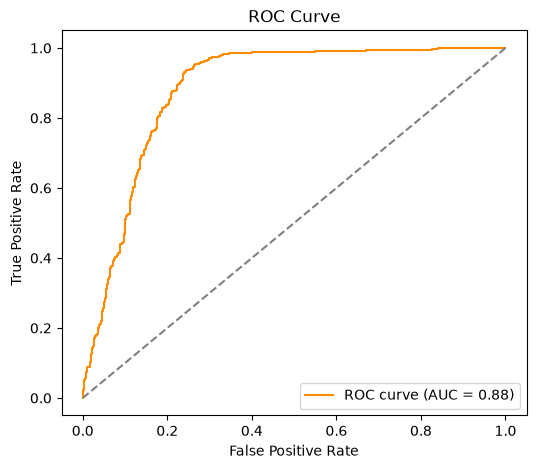

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})', color='darkorange')
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()